Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below: 


In [1]:
NAME = "Robert van der Leeuw"
STUDENT_NUMBER = "s1190941"

### Important: When handing in your homework:
- Hand in the notebook named as follows: Studentname_snumber.ipynb
- If you find any mistakes/have suggestions/like to complain about the material, please e-mail Emma at `emma.gerritse@ru.nl`
- Do not remove any cells in the notebook, as it might break the auto-grader
- When using platforms other than Jupyter Labs to make your assignments, it might add additional metadata to the Jupyter Notebook file, which will break the autograder. To prevent this, please copy the answers back into the original notebook.
- It is okay to use VS Code or PyCharm. If you want to be sure if your favorite editor is allowed, please ask your TA for help, or check manually. Google Colab is known to add extra metadata, so please do not use this, or copy back the cells to an empty file.  
- Only type your answers in places where asked.
- Before handing in your Notebook, make sure to run `Kernel > Restart Kernel and Run All Cells` one more time, and make sure it runs to the last cell without raising any errors. 

To make sure your answers work correctly, please make sure to use the variable names as given in the assignment. This will look like:

```
    some_variablename = None

    # YOUR CODE HERE
    raise NotImplementedError()
```
You have to remove the `raise NotImplementedError()` and answer the assignment as follows:

```
    some_variablename = None
    # YOUR CODE HERE
    your_code
    more_code
    some_variable = some_results
```

Not using the specified variable names may result in reduced points.

---

# Assignment 1: Math Refresh, Regression, Using data

## Deadline: September 15th, 23:59

In this assignment, we are going to do the following things:
- Refresh Numpy/Linalg knowledge
- Implement linear regression
- Take a look at the loss function
- Implement gradient descent
- Take a look at a real dataset 

To pass this assignment, make sure to give all questions a serious try. If you get stuck at some point in part 2.1, feel free to skip to 2.2. 

# Before you start:

For this course, we will make use of a Conda environment, find more about them [here](https://docs.conda.io/projects/conda/en/latest/user-guide/tasks/manage-environments.html). This is to prevent the settings in this course from conflicting with those in other courses. Please open your command line or wherever you start your Notebook from, and run the following

```
conda create -n fdtm python=3.14 scikit-learn=1.9.0 numpy=2.5.1 pandas=3.0.5 ipython seaborn==0.13.2 matplotlib holoviews==1.23.1 jupyterlab mlxtend==0.25.0
conda activate fdtm
pip install plotly==7.0.0
```

This creates a Conda environment called `fdtm` and installs the packages above. 
You can then run this environment by typing
```
conda activate fdtm
```

And you can start a Jupyter Notebook by using 

```
jupyter lab
```

You will probably need to restart this notebook, to make sure you are using the notebook from the correct environment. 


Make sure to deactivate when you start using Python outside this course, as you might create conflicts with the packages by installing other packages, you can do this by running
```
deactivate
```



We'll immediately import all packages needed in this exercise:
You can then also see if you installed the Conda environment correctly. 

In [2]:
# All imports needed for this exercise set:
import numpy as np
import time
import pandas as pd
from sklearn.linear_model import LinearRegression
import holoviews as hv
from holoviews import opts

# Recommended part to make in week 1

## Introduction to Array Programming and Numpy refresher:

In the tutorial sessions, we will be using Numpy a lot. 

Numpy has most of its backend code written in C. This makes it much faster than Python! Often in Machine Learning, we handle large datasets. Programming in Python is very convenient since many ML packages are written for it; however, it's not very fast. By using Numpy's C backend, we can speed up the process by a factor of 100. That's the difference between waiting a day or 14 minutes for a piece of code to run. Please use the built-in NumPy functions as much as possible, and refrain from using for-loops.

Every time you want to make a for-loop in this course, try to think first, "Can I do this using NumPy instead?"

Let's look at the use of NumPy with some examples:

### Exercise 1.1


Use the [numpy random normal](https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html) function to generate a random array with variable name `random` of length 1000000, mean of 0 and standard deviation of 1. 

In [3]:
np.random.seed(seed=42)  # Random seed to make all answers reproducible

M = 1000000
mu = 0
sigma = 1
random = np.random.normal(0, 1, 1_000_000)
print(f"Created random of size {random.size}, the first 6 elements are {random[0:5]}")

Created random of size 1000000, the first 6 elements are [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]


In [4]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 1.2.a

First, use a _Regular Python for-loop_ to compute the sum of _random_

In [5]:
start = time.time()

sum_random = 0
# YOUR CODE HERE
for x in random: sum_random += x

end = time.time()
forloop_sumtime = end - start

# Comment: f-strings are really useful for printing things. If you've never seen them before, check out the documentation
# https://docs.python.org/3/tutorial/inputoutput.html
# In short, put your variable between the {} brackets
# And :.3f means 'round off this float on 3 decimals'
print(f"Summed to {sum_random:.1f} in {forloop_sumtime:.3f} seconds using a forloop")

Summed to -1599.8 in 0.150 seconds using a forloop


### Exercise 1.2.b

Use the [Numpy Sum](https://numpy.org/doc/stable/reference/generated/numpy.sum.html) function to compute the sum of random

In [6]:
start = time.time()

sum_numpy = 0
# YOUR CODE HERE
sum_numpy = random.sum()

end = time.time()

numpy_sumtime = end - start
print(
    f"Summed to {sum_numpy:.1f} in {numpy_sumtime:.4f} seconds. This is {forloop_sumtime/numpy_sumtime:.2f} times faster than the forloop time"
)

Summed to -1599.8 in 0.0010 seconds. This is 155.40 times faster than the forloop time


In [7]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

As you can see, using the built-in Numpy functions is much faster! For every piece of code you write, try looking for a built-in Numpy function that does exactly that thing.

Here are some that might be handy:

_Note: In many places of this course, we will encourage you to figure out how certain functions work _from the documentation_. In machine learning, new libraries are being made every day, so learning how to read documentation is a very valuable skill._




### Making new matrices: 

[Linspace](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) , [Arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html): Return evenly spaced numbers over a specified interval.

[Ones](https://numpy.org/doc/stable/reference/generated/numpy.ones.html) , [Zeros](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html) and [Eye](https://numpy.org/devdocs/reference/generated/numpy.eye.html): Create matrices filled with ones, zeros, or the identity matrix 

### Making matrices from existing matrices: 

[Concatenate](https://numpy.org/doc/stable/reference/generated/numpy.concatenate.html): Concatenate two matrices

[Reshape](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html) : Change the dimensions, for example from a 1x6 matrix to a 2x3 matrix. 

### Common matrix operations

[Matmul](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html) : Matrix multiplication

[Transposing](https://numpy.org/doc/stable/reference/generated/numpy.transpose.html) :  Transposing a matrix

[Sum](https://numpy.org/doc/stable/reference/generated/numpy.sum.html) : Taking the sum of a matrix

[Mean](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) : Compute the mean of a matrix

[Square](https://numpy.org/doc/stable/reference/generated/numpy.square.html) : Pointwise squaring of all elements

[Multiply](https://numpy.org/doc/stable/reference/generated/numpy.multiply.html) : Pointwise multiplying elements of two arrays. (so $ \begin{pmatrix}
2 & 3 \\
\end{pmatrix} \cdot  \begin{pmatrix}
5 & 7 \\
\end{pmatrix} = \begin{pmatrix}
10 & 21 \\
\end{pmatrix}$ )

Open all of these and familiarize yourself with them. 

### Broadcasting:

One very handy feature of NumPy is called [broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) . This is a process where you can do operations between arrays of diffent sizes, as long as you can "broadcast" them into the same size. Let's look at two examples described in the NumPy documentation: 


In [8]:
a = np.array([1.0, 2.0, 3.0])
print(f"a: \n {a}")
b = 2.0
print(f"b:\n {b}")
print(f"The result of a*b is: \n {a * b}")

a: 
 [1. 2. 3.]
b:
 2.0
The result of a*b is: 
 [2. 4. 6.]


What happens above is that $b$ is broadcasted into the array `[2.0, 2.0, 2.0]`, and that will be pointwise multiplied with the array `[1.0, 2.0, 3.0]`, resulting into the result above. 


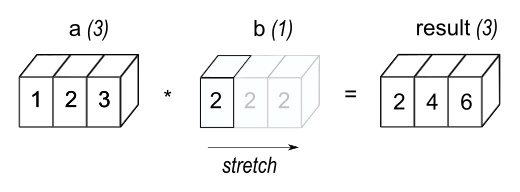

We can also use this with matrices and arrays, for example using the following:

In [9]:
a = np.array(
    [[0.0, 0.0, 0.0], [10.0, 10.0, 10.0], [20.0, 20.0, 20.0], [30.0, 30.0, 30.0]]
)
b = np.array([1.0, 2.0, 3.0])

print(f"a: \n {a}")
print(f"b: \n {b}")
print(f"The result of a+b is: \n {a + b}")



a: 
 [[ 0.  0.  0.]
 [10. 10. 10.]
 [20. 20. 20.]
 [30. 30. 30.]]
b: 
 [1. 2. 3.]
The result of a+b is: 
 [[ 1.  2.  3.]
 [11. 12. 13.]
 [21. 22. 23.]
 [31. 32. 33.]]


Here, again, the array $b$ is broadcasted into the matrix 

$$ b = \begin{pmatrix}
1 & 2 & 3\\
1 & 2 & 3\\
1 & 2 & 3\\
1 & 2 & 3\\
\end{pmatrix} $$
, and that will be pointwise added to the matrix $a$


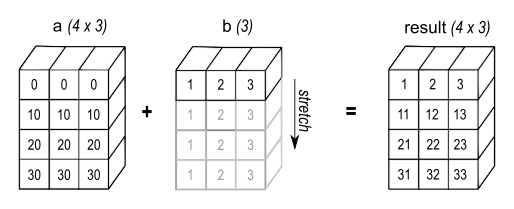!

Make sure to read the rest of the page about [broadcasting](http://numpy.org/doc/stable/user/basics.broadcasting.html), and make sure to refer back to it when you run into dimension/shape problems later on.

### Exercise 1.3

Just like with linear algebra, the _shape_ or _dimensions_ of matrices are important when computing results with NumPy. 

Remember that we can make a vector in NumPy by using `np.array()` 
In these assignments, since we will have to do matrix multiplications, it's important to keep the dimensions in mind. 

Let's look at the following vectors and matrices $A$, $B$ and $C$. :
Use [numpy's shape](https://numpy.org/doc/stable/reference/generated/numpy.shape.html) function to figure out their **shape** or **dimensions**. 
Check the dimensions of the following matrix multiplications. If they are not valid, leave the variable as `None`. :

Note: Some of these are made such that they give an error of shape incompatibility. This is done on purpose because you will probably encounter these errors pretty often during the course. 

- $A \cdot C$
- $B \cdot C$
- $C \cdot C$
- $A.T \cdot A$
- $A \cdot A.T$




In [10]:
A = np.array([[1], [2], [3]])
B = np.array([[1, 2, 3]])
C = np.array([1, 2, 3])

In [11]:
# Example answer:
A_shape = (3, 1)  # The shape of A is 3x1
A_A_shape = None  # We cannot multiply a 3x1 with a 3x1 matrix, so the shape is None
A_B_shape = (3, 3) # The shape of multiplying a 3x1 and a 1x3 matrix will be a 3x3 matrix.

# Variables to use in your answer
B_shape = (1, 3)  # Use this variable for the shape of B
C_shape = (3, )  # Use this variable for the shape of C
A_C_shape = None  # Use this variable for the shape of A*C
B_C_shape = (1, )  # Use this variable for the shape of B*C
C_C_shape = None  # Use this variable for the shape of C*C
AT_A_shape = (1, 1)  # Use this variable for the shape of A^T*A
A_AT_shape = (3, 3)  # Use this variable for the shape of A*A^T

In [12]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 1.4
Solve the exercises below, given:
$ A = \begin{pmatrix}
5 & 0 & 7
\end{pmatrix} \  , B = \begin{pmatrix}
3 & 11 & 13
\end{pmatrix},\  c = 3, \ d = 5$

You should be able to solve all of them with _one line_ of code. You can solve all assignments using the NumPy functions given above and _without_ using for-loops, list comprehensions, or accessing individual elements of the arrays.
#### Exercise 1.4.1
Create the following matrix:
$$ E = \begin{pmatrix}
0 & 0 & 0\\
0 & 0 & 0
\end{pmatrix} $$

#### Exercise 1.4.2
Compute the sum of all even natural numbers starting with 0 up to and including 20

#### Exercise 1.4.3
Compute the mean of all even natural numbers starting with 0 up to and including 20

#### Exercise 1.4.4
Given $A$ as above, compute $A^T$

#### Exercise 1.4.5
Given the matrix $A$ as above with elements $\begin{pmatrix}
a_1 & a_2 & a_3
\end{pmatrix}$ and the constants $c,d$, compute 
$$F = \begin{pmatrix} c\cdot a_1 + d & c\cdot a_2 +d & c\cdot a_3 + d \end{pmatrix} $$

#### Exercise 1.4.6
Given a vector $A$ with elements $\begin{pmatrix}
a_1 & a_2 & a_3
\end{pmatrix}$ and $B = \begin{pmatrix} b_1 & b_2& b_3 \end{pmatrix}$, compute :
$$G =  (a_1\cdot b_1, a_2\cdot b_2, a_3\cdot b_3)$$

#### Exercise 1.4.7
Using matrix multiplication and transposition, compute $h = a_1\cdot b_1 + a_2 \cdot b_2 + a_3 \cdot b_3$

#### Exercise 1.4.8
Given a vector A with elements $\begin{pmatrix}
a_1 & a_2 & a_3
\end{pmatrix}$, compute  the pointwise squared matrix $$ I = \begin{pmatrix}
a_1^2 & a_2^2 & a_3^2
\end{pmatrix}$$

#### Exercise 1.4.9
Create an array $J$ starting from 0 to 10 with 35 elements evenly spaced out

#### Exercise 1.4.10
Arrange them in a 5 x 7 matrix $K$:

#### Exercise 1.4.11
Reshape $A$ from a (1,n) to a (n,) vector called $L$

In [13]:
# Matrices and variables as given as above, do not change:

A = np.array([[5, 0, 7]])
B = np.array([[3, 11, 13]])
c = 3
d = 5

In [14]:
E = np.zeros((2, 3))  # (2,3) matrix of zeros
sum_x = np.arange(21).sum()  # Sum of all even numbers between 0 and 20
mean_x = np.arange(21, step=2).mean()  # Mean of all even numbers between 0 and 20
A_T = A.T  # Transposed matrix of A
F = c * A + d  # (c*a_1 + d, c*a_2 + d, c*a_3 + d)
G = A * B  # pointwise multiply
h = A @ B.T  # a_1*b_1 + a_2*b_2 + a_3*b_3
I = np.square(A)  # pointwise squared
J = np.random.choice(11, 35)  # 35 elements starting from 0 to 10
K = np.reshape(J, (5, 7))  # previous arranged in 5 x 7 matrix
L = np.reshape(A, np.prod(A.shape))  # A reshaped to (n,) vector

In [15]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.5

NumPy also has some convenient tools for slicing and indexing, you can read about that [here](https://numpy.org/doc/stable/user/basics.indexing.html)

Given the matrix $M$, use slicing and indexing to get the following elements out of $M$:
Use $M$ in all of your answers

$$ M = \begin{pmatrix}
0 & 1 & 2 & 3\\
4 & 5 & 6 & 7 \\
8 & 9 & 10 & 11 \\
12 & 13 & 14 & 15
\end{pmatrix} $$

#### Exercise 1.5.a
$m1 = 0$ 

### Exercise 1.5.b
$m2 = 15$, hint: use negative indexes

### Exercise 1.5.c
$$ M3 = \begin{pmatrix}
0 & 1 & 2 & 3\\
\end{pmatrix} $$

### Exercise 1.5.d
$$ M4 = \begin{pmatrix}
0 & 2 \\
\end{pmatrix} $$

### Exercise 1.5.e
$$ M5 = \begin{pmatrix}
0 \\
4  \\
8  \\
12 
\end{pmatrix} $$

### Exercise 1.5.f
$$ M6 = \begin{pmatrix}
5 & 6 \\
9 & 10  \\
\end{pmatrix} $$

### Exercise 1.5.g
$$ M7 = \begin{pmatrix}
3 & 2 & 1 & 0\\
\end{pmatrix} $$

In [16]:
M = np.arange(0, 16).reshape((4, 4))

m1 = M[0, 0]
m2 = M[-1, -1]
M3 = M[0]
M4 = M[0, :3:2]
M5 = M[:, 0]
M6 = M[1:3, 1:3]
M7 = M[0, ::-1]

In [17]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

Well done! You have made the recommended part for week 1! You can continue working on this set after having had the lecture in week 2. 

# Recommended part to make in week 2:
**What follows will make use of the knowledge gained in _Lecture 2_ .**

**You can work ahead if you want to, but the TAs might not be able to answer your questions.**

### Exercise 2.1.1

In these sets of assignments, we implement our gradient descent! We will get started with a small toy dataset. 
This is often a good idea in practice, since our models can get fairly complicated and our datasets fairly big. Having small datasets will make the iterations of testing our algorithms easier, and will also make it easier to debug your code. 

First, let's make an example NumPy array `X` with shape (11,1); having 11 elements equally spaced from 0 up to and including 10. Make the NumPy array `y` with shape (11,), with numbers equally spaced from 4 up to and including 24. (Hint, use for example [numpy.linspace](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) )

_note_ : It is important in this case for X to be in shape (11,1) instead of (11,). Otherwise, it will be difficult to use the same code for multiple dimensions. 


In [18]:
N = 11
X = np.random.choice(11, (11, 1))
y = np.random.choice(np.arange(4, 25), 11)

print(X.shape, y.shape) # (Check that these are (11,1) and (11,))

(11, 1) (11,)


In [19]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

In [20]:
# Let's add a little bit of random noise to y, this will make it a little bit more effort to actually learn something.
np.random.seed(seed=42)
y = y + np.random.normal(0, 0.5, N)

Great! Visualization is very important. 
There are many different libraries in Python for making plots. The most popular are [Matplotlib](https://matplotlib.org/) and its extension [Seaborn](https://seaborn.pydata.org/). 

For an overview of all available plotting libraries in Python, and how they relate to eachother, check out [PyViz](https://pyviz.org/overviews/index.html).

We'll be using HvPlot for plotting this year, which is a high level plotting library build so you can easily switch renderers. We will start plotting using Bokeh as backend, but you can also switch to other backends like Matplotlib, which you might have seen before. 

You are free to use Matplotlib or Seaborn as well, whenever you are required to make plots for exercises, if you don't want to struggle through the PyViz documentation.

Let's make a plot of our generated data:

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
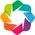

:Scatter   [x]   (y)

In [21]:
hv.extension("bokeh")
hv.renderer("bokeh").webgl = False

fig = hv.Scatter((X, y))
fig

### Exercise 2.1.2

What do you think will be the linear equation predicting this relationship? 

Looking at the chart, I assume Cov(x, y) > 0, therefore Corr(x, y) > 0. I think y ~= 0+1.5x. - EDIT: Rerunning all cells completely changed the trend :(

Remember that in the lectures, we gave all code using the weight matrix $w$ and added a column with constant ones. This is common in _machine learning math language_. However, in _machine learning coding_ we will often write this weight for the constant as the _bias_ value.

So for example, given the dataset $X = (1, 2, 3)$ and $y = (8, 11, 14)$, we can express this using the function $h(x) = 5 + 3x$.

In _math language_, we would change the dataset $X$ to the dataset $X = ((1,1), (1,2), (1,3))$, we would use the weights $w = (5,3)$, and then express our hypothesis function as $h(x) =  X \cdot w$. This elegant and short notation makes it easier to derive proofs. 

In _coding_, it is not very efficient to add a column with only ones to your database. That is why, we will keep our database $X = (1, 2, 3)$, set our weights as $weights = (3)$ and have a bias value $bias = 5$. We will then write our hypothesis function as $h(x) = X \cdot weight + bias$


### Exercise 2.1.3

Make a function that given a matrix X of shape (N,m), a weight matrix of shape (m,1) and a float value bias, make the hypothesis function 

$h(x) = X\cdot weight + bias$

Make sure the resulting vector has _the same shape as y_

Hint: make use of Numpy, and take a look at your answers in Exercise 1.4

In [22]:
def evaluate_set(X, weight, bias):
    return X @ weight + bias

In [23]:
# Test with the function you estimated
weight = np.array([2])
bias = 4
y_prime = evaluate_set(X, weight, bias)
print(X.shape)
print(weight.shape)
print(y.shape)
print(y_prime.shape)

(11, 1)
(1,)
(11,)
(11,)


In [24]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.4

Great! Now we want to see how well we did. For that, we will implement the least squared error.

$$J(w) = \frac{1}{2} \sum_i ( h_w(x^{(i)}) - y^{(i)} )^2$$

The squared error is a function that takes the results of the hypothesis function called `y_prime` and the true values of `y` as input and outputs a score (which is a floating point value).

Tip: try solving it again just using Numpy functions, without forloops. 
If you're stuck, try it out on a small example first.


In [25]:
def least_squared_error(y_prime, y):
    # Input, two array lists of dimensions (N,)
    # Output: floating point value

    diff_square = np.vectorize(lambda prediction, actual: np.power((prediction - actual), 2))
    
    return np.sum(diff_square(y_prime, y)) / 2

# assert isinstance(least_squared_error(y_prime, y), np.float64), "Wrong shape, expected scalar"
# assert least_squared_error(y, y) == 0, "LSE =/= 0 on perfect prediction, what?"

### Exercise 2.1.5

Given this least square function, a weight array and a bias value, compute the least squared error. Change around the values for weights and bias, and see how this impacts the least squared score.

In [26]:
weight = np.array([3])
bias = 0.5
least_squared = least_squared_error(evaluate_set(X, weight, bias), y)

print(least_squared)

660.1864466016248


In [27]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

Now, we can make a a plot of the error function using different weights.

For this, we will use a trick called a [mesh grid](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html) .
Note that you do not need to understand how to make a mesh grid now, only how to interpret the result in the end. 

Mesh grids are a way of making a 2D coordinate system, which is useful for creating plots. 

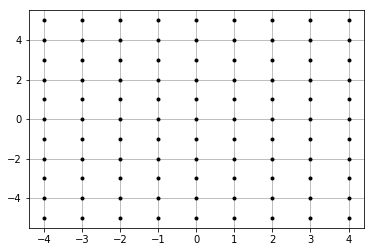!

This will create two 2D arrays containing the X-value and the Y-value of the array.

We can then vectorize our least squared error function over these two mesh-grids, similar to how one would use the map function in Functional Programming.



In [28]:
# First creating a linear space of the dimensions we want our plot to go over

weights_plot = np.linspace(-6, 6, 130)
bias_plot = np.linspace(-6, 6, 130)  # NOTE: Played around with the axis, seemed like better params higher up

# Next we will create our mesh grid, this will create two 2-D arrays. One contains the x-value,
# and one contains the y-value
ww, bb = np.meshgrid(weights_plot, bias_plot)


# np.vectorize is very similar to a map in functional programming, and allows us
# to be able to use any function on an entire array
@np.vectorize
def vectorized_LSE(weights, bias):
    return least_squared_error(evaluate_set(X, np.array([weights]), bias), y)


LSE = vectorized_LSE(ww, bb)

image = hv.Image(
    (weights_plot, bias_plot, LSE),
    kdims=["Weight", "Bias"],
    vdims=["LSE"],
)

image.opts(
    cmap="Plasma",
    logz=True,
    colorbar=True,
    width=600,
    height=600,
    xlabel="Weight",
    ylabel="Bias",
    tools=["hover"]

)

contours = hv.operation.contours(image, levels=15).opts(logz=True)

# We can plot images over each other by multiplying, and add multiple next to each other by adding
image * contours

:Overlay
   .Image.I    :Image   [Weight,Bias]   (LSE)
   .Contours.I :Contours   [Weight,Bias]   (LSE)

### Exercise 2.1.6


By exploring the plot above, which values of x and y seem to be the best? 

Note: You do not have to write a function to find the result, you can just manually inspect the figure and find the values you think are the best. 
The autograder will detect your answer as correct as long as you are 0.1 close. 

In [29]:
best_weight = 1
best_bias = 6

In [30]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.7.a

We have now seen the _feature space_ of this regression problem, we are now going to solve this using linear regression. For that, we first have to implement the function giving the _gradient_ of the least squared error. Remember that the gradient function for our Least Squared Error loss function

$$J(w) = \frac{1}{2} \sum_i ( h_w(x^{(i)}) - y^{(i)} )^2$$

Equals

$$\frac{\partial}{\partial  w_j } J(w) = \sum_i ( h_w(x^{(i)}) - y^{(i)} )\cdot x_j^{(i)}$$


Complete the function `gradient`, which gets x, y, current weights, bias, and returns the tuple $$(\frac{\partial}{\partial  w_0 } J(w), \frac{\partial}{\partial  w_1 } J(w))$$
Make sure that `dw0` is a (1,) NumPy Array, and `dw1` is a numeric value. 

Hint: Note that when updating `dw0`, $x_0^{(i)} = 1$.


In [31]:
def gradient(x, y, weights, bias):
    y_pred = evaluate_set(x, weights, bias)

    dw0 = (y_pred - y) @ np.ones((y.shape[0], 1))
    dw1 = (y_pred - y) @ x

    if len(dw1) == 1: dw1 = dw1[0]  # TODO: Better solution?
    
    return dw0, dw1

# gradient(X, y, np.array([1]), 6)
#dw0, dw1 = gradient(X, y, weight, bias)
#assert dw0.shape == (1,) and isinstance(dw1, np.float64), f"Wrong output shapes"


In [32]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

Let us test if we did our gradient correctly, let us plot the gradients for points in our vector field.

We'll put some [Vector field](https://holoviews.org/reference/elements/bokeh/VectorField.html) on the gradient we made before.  

In case you get an error, make sure that the output of `gradient` is in the correct format. The arrows should be pointing inwards. 

In [33]:
# Using np.vectorize again
weightsv_plot = np.linspace(-6, 6, 60)
biasv_plot = np.linspace(-6, 6, 60)
wwv, bbv = np.meshgrid(weightsv_plot, biasv_plot)

@np.vectorize
def vectorized_weights(weights, bias):
    return gradient(X, y, [weights], bias)[0][0]
    
@np.vectorize
def vectorized_bias(weights, bias):
    return gradient(X, y, [weights], bias)[1]

W = vectorized_weights(wwv, bbv)
B = vectorized_bias(wwv,bbv)

# convert W, B to magnitude and angle, which we need for plotting
mag = np.sqrt(W**2 + B**2)
angle = (np.pi / 2.) - np.arctan2(W / mag, B / mag)

vectorfield = hv.VectorField((weightsv_plot, biasv_plot, angle, np.log10(mag)))

vectorfield.opts(
    opts.VectorField(
        magnitude="Magnitude",
        logz=True,
        color="white",
        colorbar=True,
        width=700,
        height=600,
        tools=["hover"]
    )
)

image * vectorfield

:Overlay
   .Image.I       :Image   [Weight,Bias]   (LSE)
   .VectorField.I :VectorField   [x,y]   (Angle,Magnitude)

### Exercise 2.1.7.b


Filling that in in the gradient descent algorithm

$$ w_j := w_j - \alpha \frac{\partial}{\partial  w_j } J(w)$$

This gives us our update rule for every step:

$$ w_j := w_j + \alpha \sum_i ( y^{(i)} - h_w(x^{(i)}))\cdot x_j^{(i)} $$

Complete the function for our gradient descent algorithm, by using the previously defined `evaluate_set` for $h(x)$. 

hint:
Use the gradient function before
Since we split _weights_ and _bias_ into two separate variables, you also need to separately update them. 

For each step, we should have something like

- Compute dw and db, the results of the gradient function before

- weights = weight + .... (resulting in a np array in the same shape as weights)

- bias = bias + ... (resulting in a float)

To check if you implemented things correctly, print the shape of `result` and `weights` after each iteration, They should stay the same. Start with a small number of iterations. 

We will add two arrays `all_weight` and `all_bias`, so we can plot the path of the gradient later.


In [34]:
def gradient_descent(x, y, lr, steps):
    N, dim = x.shape
    weights = np.ones((dim))
    bias = 0
    all_weights = [weights[0]]
    all_bias = [bias]
    for i in range(steps):
        dw0, dw1 = gradient(x, y, weights, bias)

        bias -= lr * dw0[0]
        weights -= lr * dw1
        
        all_weights.append(weights[0])
        all_bias.append(bias)
    return weights, bias, all_weights, all_bias

### Exercise 2.1.8

Play around with the values of learning_rate and steps until you get an acceptable answer, which is close to the values you found in 2.1.6. 
You can use this to check if your implementation is correct. 

In [35]:
learning_rate = 0.0001  # Higher is unstable
steps = 200  # Enough to converge

p_weights, p_bias, weightvec, biasvec = gradient_descent(X, y, learning_rate, steps)
print(p_weights, p_bias)

[1.74939116] 0.6189094364859917


We will plot the path of your gradient descent on top of the plot we made before, to help you identify if you implemented it correctly:

In [36]:
trace = hv.Scatter((weightvec, biasvec))

image * vectorfield * trace

:Overlay
   .Image.I       :Image   [Weight,Bias]   (LSE)
   .VectorField.I :VectorField   [x,y]   (Angle,Magnitude)
   .Scatter.I     :Scatter   [x]   (y)

In [37]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.9

Use these newly found values for weight and bias, predict the value of `y_prime`, and compute the least squared error for those values.
Change the values of learning_rate and steps above, until your least squared error gets smaller than 10.


In [38]:
y_prime = evaluate_set(X, p_weights, p_bias) ## Assign the result of evaluate_set to this variable
current_error = least_squared_error(y_prime, y)  ## Assign the result of least_squared_error to this variable

In [39]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

In [40]:
# Use the following plot to see if your prediction is logical

scatter_true = hv.Scatter((X,y), label='Ground truth').opts(size=10,
    width=800,
    height=800)
scatter_predicted = hv.Curve((X,y_prime), label='Prediction').opts( tools = ['hover'])

scatter_true * scatter_predicted

:Overlay
   .Scatter.Ground_truth :Scatter   [x]   (y)
   .Curve.Prediction     :Curve   [x]   (y)

## Exercise 2.2.1: Testing on a real dataset:

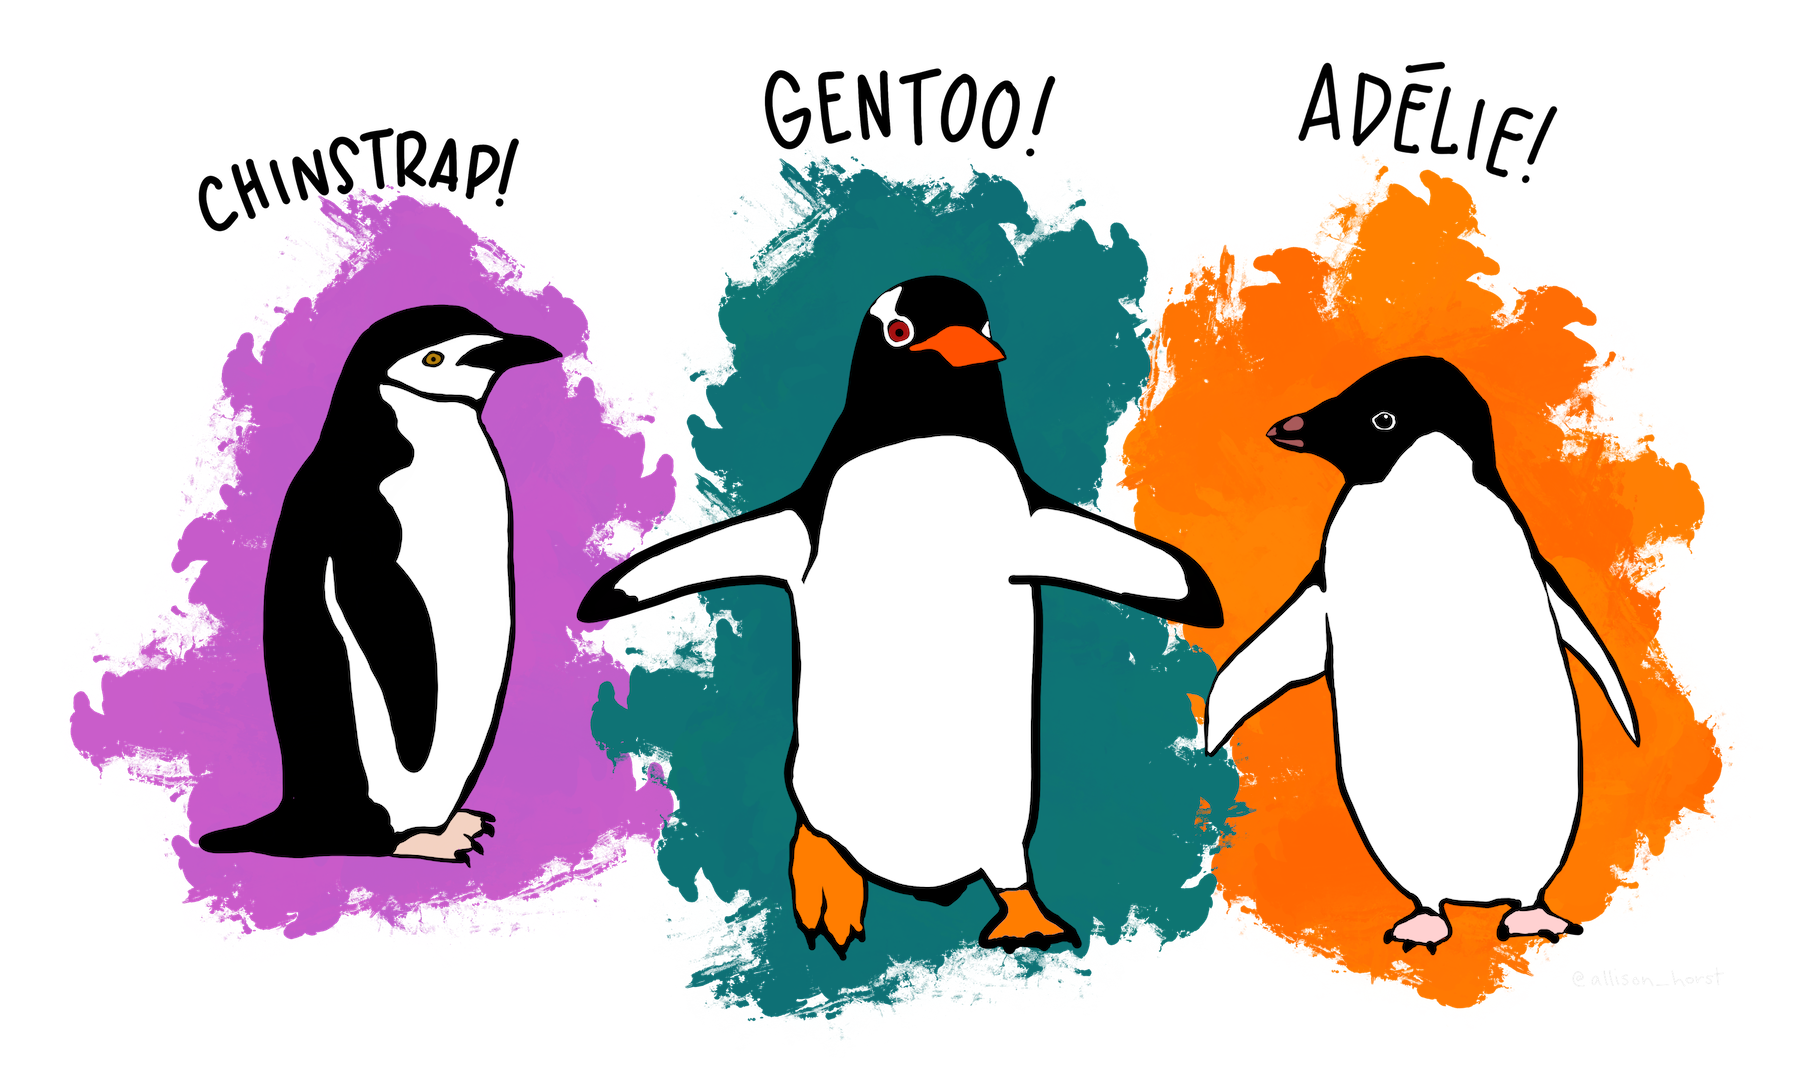!

Seems to work pretty well, hopefully! Let's test it on a real dataset! For this, we use the Penguin dataset, read more [here](https://github.com/allisonhorst/palmerpenguins).


In [41]:
# Downloading the penguin dataset using curl https://curl.se/docs/tutorial.html.
!curl -o penguin.csv https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
100  13478 100  13478   0      0  98529      0                              0


In [42]:
# Loading the data
penguins = pd.read_csv("penguin.csv")
# To make our live easier, let's drop all the NaN values (We'll learn to deal with this later)
penguins = penguins.dropna()
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


### Exercise 2.2.2
Plot the data using [Holoviews 3D plots, using Plotly as backend instead of Bokeh](https://holoviews.org/reference/elements/matplotlib/Scatter3D.html)

Play around trying to change things in the lay-out, coloring, or use of markers.

In [43]:
# Plotting the data in 3D:
# Try playing around with the parameters in the plot below:

hv.extension('plotly')
scatter3d = hv.Scatter3D(penguins, kdims=["bill_length_mm", "flipper_length_mm", "body_mass_g"], vdims=["species"]).groupby("species").overlay().opts(show_legend=True,
    width=800,
    height=800)
scatter3d


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:NdOverlay   [species]
   :Scatter3D   [bill_length_mm,flipper_length_mm,body_mass_g]   (species)

### Exercise 2.2.3

Since we have three different species of Penguins, we see some possible correlation between bill length, body mass and flipper length. 
However, we also see that these three species of penguins are clearly separated within the plots. For that reason, let us just focus on the Gentoo penguins. 

For that, first make a dataframe called gentoo_penguins, in which we store the dataframe but only when the `species` column equals `Gentoo`. [Check how to filter dataframes here](https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html)

Next, make 2 numpy arrays, the first one called `penguin_X`, which contains the $(N,2)$ array of the x_features 
`['bill_length_mm', 'flipper_length_mm']`, and the `penguin_y` which contains the $(N,)$ shaped NumPy array containing `['body_mass_g']`


In [44]:

x_features = ["bill_length_mm", "flipper_length_mm"]
y_features = ["body_mass_g"]

gentoo_penguins = penguins[penguins["species"] == "Gentoo"]
penguin_X = gentoo_penguins[x_features].to_numpy()
penguin_y = gentoo_penguins[y_features].to_numpy().flatten()


# Note that the values for bill_length_mm are between 10 and 100, for flipper length are between 100 and 1000
# and for body_mass_g, the values are between 1000 and 10000. To make our life with gradient descent a little bit easier
# We will multiply the arrays with a value to make sure all our values are between 0.1 and 1
penguin_X = np.multiply(penguin_X, np.array([0.01, 0.001]))
penguin_y = penguin_y * 0.0001

In [45]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""



'DO NOT MODIFY THIS CELL'

In [46]:
penguin_y.shape

(119,)

In [47]:
# Use this plot to inspect the values of penguin_X and penguin_y

scatter3d_true = hv.Scatter3D((penguin_X[:, 0], penguin_X[:, 1], penguin_y)).opts(size=4,
    xlabel=x_features[0],
    ylabel=x_features[1],
    zlabel=y_features[0],
    width=800,
    height=800)
scatter3d_true


:Scatter3D   [x,y,z]

### Exercise 2.2.4

Now we can do Gradient Descent to learn about the penguins! Use the function `gradient_descent` you created above, and try experimenting with `learning_rate` and `steps` to find a value for `penguin_weights` and `penguin_bias`. 
Are these values what you expected, given the plot above?



In [48]:
learning_rate = 0.01
steps = 5000

penguin_weights, penguin_bias, _, _ = gradient_descent(
    penguin_X, penguin_y, learning_rate, steps
)

print(penguin_weights, penguin_bias)

[0.89527123 1.31415865] -0.20209304396626857


In [49]:
"""Checks whether previous output is correct"""

"""DO NOT MODIFY THIS CELL"""



'DO NOT MODIFY THIS CELL'

### Exercise 2.2.5

Predict the values of the weight of the penguins with the `evaluate_set` function, and plot the values of `penguin_X` together and add them to the plot below: 
Also use `current_error` to compute the least squared error, given `penguin_y` and the predicted weight values of the penguins. 

In [50]:
penguin_pred = evaluate_set(penguin_X, penguin_weights, penguin_bias)
current_error = least_squared_error(penguin_pred, penguin_y)  # Assign the result of least_squared_error to this variable

In [51]:
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

In [52]:

# Add a trace with the predictions instead of the true values of y, called scatter3d_pred,.

scatter3d_pred = hv.Scatter3D((penguin_X[:, 0], penguin_X[:, 1], penguin_pred)).opts(size=4,
    xlabel=x_features[0],
    ylabel=x_features[1],
    zlabel=y_features[0],
    width=800,
    height=800)

# Plotting two traces on top of eachother:
scatter3d_true * scatter3d_pred


:Overlay
   .Scatter3D.I  :Scatter3D   [x,y,z]
   .Scatter3D.II :Scatter3D   [x,y,z]

### Exercise 2.3.1: The package

Congratulations! You have now implemented linear regression by hand. This has been a good exercise to further your understanding; however, whenever you use linear regression in the future, it's best to use the official package. Careless mistakes can happen quickly, so using a carefully maintained package will reduce the chance of your research results being wrong.


For the last bit of the assignment, let us use the linear regression module in Sk Learn.
You can read up on it here, or use the `help` command on the function: 
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html



Use again as features for `X` `bill_length_mm` and `flipper_length_mm`, and as feature for `y` `body_mass_g`.
Make sure you have some np array in which you store the predicted values for `y`. 


In [53]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(penguin_X, penguin_y)
sk_pred = reg.predict(penguin_X)

### Exercise 2.3.2: The package
Make a plot similar to the plot in exercise `2.2.5`, where we plot two traces: `bill_length_mm` and `flipper_length_mm`, the true `body_mass_g` and the predicted value for `body_mass_g` you obtained in the last cell. 

In [54]:
scatter3d_pred_sk = hv.Scatter3D((penguin_X[:, 0], penguin_X[:, 1], sk_pred)).opts(size=4,
    xlabel=x_features[0],
    ylabel=x_features[1],
    zlabel=y_features[0],
    width=800,
    height=800)

# Plotting two traces on top of eachother:
scatter3d_true * scatter3d_pred_sk

:Overlay
   .Scatter3D.I  :Scatter3D   [x,y,z]
   .Scatter3D.II :Scatter3D   [x,y,z]